# 37 - Gemma exact-trigger calibration-transfer stress test

**Question.** Does the exact-probability-endpoint event trigger behind the
leading Gemma-timing/FinBERT-ranking hybrid transfer to an older Gemma
implementation on the same hash-matched headlines, or is it specific to model
and probability calibration?

This is a **measurement falsification**, not a scorer tournament or independent
return validation. Before reading any new return result, the comparison is
frozen to the 85,960 successful hashes shared by the older Cerebras Gemma 4
31B soft-label checkpoint and the complete DeepInfra Gemma 4 26B checkpoint.
Canonical company associations and first timestamps come from the complete
44-company checkpoint. Both scorers are aggregated identically, then restricted
to dates with all immutable original-33 companies represented.

The **calibration-transfer gate** requires both matched-coverage triggers to
have at least 60 eligible sessions, eligible-date Jaccard at least 0.50, and
positive/negative daily count correlations at least 0.50. These are deliberately
input-only conditions. If only one arm reaches 60 sessions, only that arm may
enter the unchanged FinBERT-rank, 25%-cap, one-session, 10-bps strategy as a
non-comparative stress test. Its timing gate requires an exact one-sided
all-shift p-value below 0.05, break-even above cost, and nonnegative independently
initialized half-sample Sharpes. No endpoint, threshold, cap, or model is tuned.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    build_expanded_aggregation_panel,
    load_price_exports,
    load_success_scores,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260811
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0

COLLECTION_DIR = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA31_PATH = (
    REPO_ROOT
    / "Data/collections/lseg_us_sector_33_6m/derived/headline_scores_gemma-4-31b_soft.csv"
)
GEMMA26_PATH = (
    COLLECTION_DIR
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
FINBERT_PATH = COLLECTION_DIR / "headline_scores_finbert4556_cacheonly_20260803.csv"
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
FINBERT_PANEL_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet"
)
GEMMA26_PANEL_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet"
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/37_gemma_calibration_transfer"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen hash-matched scorer inputs

Licensed headline text is never loaded. The older checkpoint has no completed
adjacent manifest, so its file hash, append-only status history, model identity,
duplicate successes, and score bounds are audited directly and its limitation
remains binding.

In [2]:
finbert_scores, finbert_input_audit = load_success_scores(FINBERT_PATH, scorer="finbert")
gemma26_scores, gemma26_input_audit = load_success_scores(GEMMA26_PATH, scorer="gemma4_26b")
gemma31_history = pd.read_csv(
    GEMMA31_PATH,
    usecols=["headline_sha256", "model_id", "label", "score", "status", "error"],
    low_memory=False,
)
gemma31_success = gemma31_history.loc[gemma31_history["status"].eq("success")].copy()
gemma31_success["score"] = pd.to_numeric(gemma31_success["score"], errors="raise")
if gemma31_success["headline_sha256"].duplicated().any():
    raise ValueError("older Gemma checkpoint has duplicate successes")
if not gemma31_success["score"].between(-1.0, 1.0).all():
    raise ValueError("older Gemma checkpoint has scores outside [-1, 1]")
model_ids = sorted(gemma31_success["model_id"].dropna().astype(str).unique())
if model_ids != ["gemma-4-31b"]:
    raise ValueError(f"unexpected older Gemma model identities: {model_ids}")

shared_hashes = set(gemma31_success["headline_sha256"]) & set(
    gemma26_scores["headline_sha256"]
)
if len(shared_hashes) != 85_960:
    raise ValueError(f"expected 85,960 shared successful hashes, found {len(shared_hashes):,}")

metadata_columns = [
    "headline_sha256",
    "matched_symbols",
    "first_timestamp",
    "explicit_target",
    "contextual",
    "market_price_technical",
]
canonical_metadata = gemma26_scores.loc[
    gemma26_scores["headline_sha256"].isin(shared_hashes), metadata_columns
].copy()


def matched_score_frame(scores: pd.DataFrame, *, scorer: str) -> pd.DataFrame:
    out = canonical_metadata.merge(
        scores[["headline_sha256", "label", "score"]],
        on="headline_sha256",
        validate="one_to_one",
    )
    if len(out) != len(shared_hashes):
        raise ValueError(f"{scorer} does not cover the shared population")
    out["scorer"] = scorer
    return out


matched_scores = {
    "gemma31_cerebras": matched_score_frame(
        gemma31_success, scorer="gemma31_cerebras"
    ),
    "gemma26_deepinfra": matched_score_frame(
        gemma26_scores, scorer="gemma26_deepinfra"
    ),
    "finbert": matched_score_frame(finbert_scores, scorer="finbert"),
}
headline_endpoint_rows = []
for scorer, frame in matched_scores.items():
    score = frame["score"].to_numpy(dtype=float)
    headline_endpoint_rows.append(
        {
            "scorer": scorer,
            "shared_headlines": len(frame),
            "unique_scores": int(frame["score"].nunique()),
            "exact_positive": int(np.isclose(score, 1.0).sum()),
            "exact_negative": int(np.isclose(score, -1.0).sum()),
            "exact_endpoint_total": int(np.isclose(np.abs(score), 1.0).sum()),
            "mean_score": float(score.mean()),
            "score_std": float(score.std(ddof=1)),
        }
    )
headline_endpoints = pd.DataFrame(headline_endpoint_rows)
input_audit = pd.DataFrame(
    [
        {
            "scorer": "gemma31_cerebras",
            "rows_including_historical_attempts": len(gemma31_history),
            "unique_successes": gemma31_success["headline_sha256"].nunique(),
            "shared_successes": len(shared_hashes),
            "duplicate_successes": int(
                gemma31_success["headline_sha256"].duplicated().sum()
            ),
            "file_sha256": sha256_file(GEMMA31_PATH),
            "completed_manifest": False,
        },
        {
            "scorer": "gemma26_deepinfra",
            "rows_including_historical_attempts": gemma26_input_audit[
                "rows_including_historical_attempts"
            ],
            "unique_successes": gemma26_input_audit["unique_successes"],
            "shared_successes": len(shared_hashes),
            "duplicate_successes": gemma26_input_audit["duplicate_successes"],
            "file_sha256": gemma26_input_audit["output_sha256"],
            "completed_manifest": True,
        },
        {
            "scorer": "finbert",
            "rows_including_historical_attempts": finbert_input_audit[
                "rows_including_historical_attempts"
            ],
            "unique_successes": finbert_input_audit["unique_successes"],
            "shared_successes": len(shared_hashes),
            "duplicate_successes": finbert_input_audit["duplicate_successes"],
            "file_sha256": finbert_input_audit["output_sha256"],
            "completed_manifest": True,
        },
    ]
)
display(input_audit)
display(headline_endpoints)

,scorer,rows_including_historical_attempts,unique_successes,shared_successes,duplicate_successes,file_sha256,completed_manifest
0,gemma31_cerebras,370405,85961,85960,0,3909dabfd0b4c6f93b5b786c4e361f159156cb42c819a4...,False
1,gemma26_deepinfra,889103,888155,85960,0,afb2d9c3029c4fba4fce3600218233a02d14051788f873...,True
2,finbert,888155,888155,85960,0,737287a167dea8f3a7f03c53f020d6606a4f0554dc105b...,True


,scorer,shared_headlines,unique_scores,exact_positive,exact_negative,exact_endpoint_total,mean_score,score_std
0,gemma31_cerebras,85960,48,838,9334,10172,0.098727,0.628214
1,gemma26_deepinfra,85960,58,52,43,95,0.124079,0.583540
2,finbert,85960,85959,0,0,0,0.104182,0.581987


## Identical firm-open aggregation and input-only transfer gate

In [3]:
prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)
original_symbols = tuple(
    symbol for members in SECTOR_MEMBERS.values() for symbol in members[:3]
)
original_set = set(original_symbols)
matched_panels = {}
association_counts = {}
for scorer, frame in matched_scores.items():
    events = map_headlines_to_entry_sessions(frame, prices)
    events = events.loc[events["symbol"].isin(original_set)].copy()
    association_counts[scorer] = len(events)
    panel = build_expanded_aggregation_panel(events, prices)
    matched_panels[scorer] = panel.loc[panel["symbol"].isin(original_set)].copy()

complete_sets = {
    scorer: set(
        panel.groupby("session_date")["symbol"]
        .nunique()
        .loc[lambda counts: counts.eq(33)]
        .index
    )
    for scorer, panel in matched_panels.items()
}
common_complete_sessions = set.intersection(*complete_sets.values())
if len(common_complete_sessions) != 118:
    raise ValueError(
        f"expected 118 common complete sessions, found {len(common_complete_sessions)}"
    )

matched_audits = {}
firm_endpoint_rows = []
for scorer, panel in matched_panels.items():
    use = panel.loc[panel["session_date"].isin(common_complete_sessions)].sort_values(
        ["session_date", "symbol"], kind="mergesort"
    )
    if len(use) != 118 * 33:
        raise RuntimeError("common matched panel is not rectangular")
    _, audit = build_exact_extrema_targets(use, single_name_cap=SINGLE_NAME_CAP)
    matched_audits[scorer] = audit
    values = use["strongest_event"].to_numpy(dtype=float)
    firm_endpoint_rows.append(
        {
            "scorer": scorer,
            "firm_open_rows": len(use),
            "exact_positive_firm_opens": int(np.isclose(values, 1.0).sum()),
            "exact_negative_firm_opens": int(np.isclose(values, -1.0).sum()),
            "eligible_sessions": int(audit["eligible"].sum()),
            "positive_event_sessions": int(audit["positive_names"].gt(0).sum()),
            "negative_event_sessions": int(audit["negative_names"].gt(0).sum()),
        }
    )
firm_endpoints = pd.DataFrame(firm_endpoint_rows)

audit31 = matched_audits["gemma31_cerebras"].set_index("session_date")
audit26 = matched_audits["gemma26_deepinfra"].set_index("session_date")
eligible31 = set(audit31.index[audit31["eligible"]])
eligible26 = set(audit26.index[audit26["eligible"]])
eligible_union = eligible31 | eligible26
eligible_jaccard = len(eligible31 & eligible26) / len(eligible_union)
positive_count_correlation = float(
    audit31["positive_names"].corr(audit26["positive_names"])
)
negative_count_correlation = float(
    audit31["negative_names"].corr(audit26["negative_names"])
)
headline_lookup = headline_endpoints.set_index("scorer")
matched_lookup = firm_endpoints.set_index("scorer")
transfer_audit = pd.DataFrame(
    [
        {
            "shared_hashes": len(shared_hashes),
            "common_complete_sessions": len(common_complete_sessions),
            "gemma31_exact_headline_endpoints": int(
                headline_lookup.loc["gemma31_cerebras", "exact_endpoint_total"]
            ),
            "gemma26_exact_headline_endpoints": int(
                headline_lookup.loc["gemma26_deepinfra", "exact_endpoint_total"]
            ),
            "endpoint_rate_ratio_31b_to_26b": float(
                headline_lookup.loc["gemma31_cerebras", "exact_endpoint_total"]
                / headline_lookup.loc["gemma26_deepinfra", "exact_endpoint_total"]
            ),
            "gemma31_eligible_sessions": int(
                matched_lookup.loc["gemma31_cerebras", "eligible_sessions"]
            ),
            "gemma26_eligible_sessions": int(
                matched_lookup.loc["gemma26_deepinfra", "eligible_sessions"]
            ),
            "eligible_date_intersection": len(eligible31 & eligible26),
            "eligible_date_union": len(eligible_union),
            "eligible_date_jaccard": eligible_jaccard,
            "positive_count_correlation": positive_count_correlation,
            "negative_count_correlation": negative_count_correlation,
        }
    ]
)
calibration_transfer_gate = bool(
    transfer_audit.loc[0, "gemma31_eligible_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and transfer_audit.loc[0, "gemma26_eligible_sessions"]
    >= MINIMUM_ACTIVE_SESSIONS
    and eligible_jaccard >= 0.50
    and positive_count_correlation >= 0.50
    and negative_count_correlation >= 0.50
)
display(firm_endpoints)
display(transfer_audit.T)
print("calibration-transfer gate:", calibration_transfer_gate)

,scorer,firm_open_rows,exact_positive_firm_opens,exact_negative_firm_opens,eligible_sessions,positive_event_sessions,negative_event_sessions
0,gemma31_cerebras,3894,210,2421,84,84,118
1,gemma26_deepinfra,3894,46,35,6,40,33
2,finbert,3894,0,0,0,0,0


,0
shared_hashes,"85,960.000000"
common_complete_sessions,118.000000
gemma31_exact_headline_endpoints,"10,172.000000"
gemma26_exact_headline_endpoints,95.000000
endpoint_rate_ratio_31b_to_26b,107.073684
gemma31_eligible_sessions,84.000000
gemma26_eligible_sessions,6.000000
eligible_date_intersection,5.000000
eligible_date_union,85.000000
eligible_date_jaccard,0.058824


calibration-transfer gate: False


## Permitted 31B-trigger strategy stress test

The matched-coverage 26B arm stops before returns because only six sessions
are eligible. The 31B arm clears the return-blind 60-session floor. Its
observed schedule is embedded unchanged in the complete 167-session grid;
dates without a rectangular 31B input panel remain cash. FinBERT ranks come
from the same complete aggregate panel used by Notebooks 34-36.

In [4]:
finbert_panel = pd.read_parquet(FINBERT_PANEL_PATH)
gemma26_panel = pd.read_parquet(GEMMA26_PANEL_PATH)
for frame in (finbert_panel, gemma26_panel):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
finbert_panel = finbert_panel.loc[finbert_panel["symbol"].isin(original_set)].copy()
gemma26_panel = gemma26_panel.loc[gemma26_panel["symbol"].isin(original_set)].copy()
sessions = pd.DatetimeIndex(sorted(finbert_panel["session_date"].unique()))
symbols = tuple(sorted(finbert_panel["symbol"].unique()))
if len(sessions) != 167 or set(symbols) != original_set:
    raise ValueError("expected the complete original-33 strategy grid")
if not finbert_panel.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("complete FinBERT rank panel is not rectangular")

schedule31 = pd.DataFrame(
    {
        "session_date": sessions,
        "eligible": False,
        "positive_names": 0,
        "negative_names": 0,
    }
).set_index("session_date")
schedule31.loc[audit31.index, ["eligible", "positive_names", "negative_names"]] = (
    audit31[["eligible", "positive_names", "negative_names"]].to_numpy()
)
schedule31 = schedule31.reset_index()
if int(schedule31["eligible"].sum()) != 84:
    raise RuntimeError("31B schedule activity changed during full-grid embedding")

ranked_symbols_by_session = {
    pd.Timestamp(session): tuple(
        day.sort_values(
            ["strongest_event", "symbol"],
            ascending=[False, True],
            kind="mergesort",
        )["symbol"]
    )
    for session, day in finbert_panel.groupby("session_date", sort=True)
}


def shifted_schedule(schedule: pd.DataFrame, shift: int) -> pd.DataFrame:
    if not 0 <= shift < len(schedule):
        raise ValueError("shift outside schedule length")
    result = schedule.copy()
    for column in ("eligible", "positive_names", "negative_names"):
        result[column] = np.roll(schedule[column].to_numpy(), shift)
    return result


def build_rank_targets(schedule: pd.DataFrame) -> tuple[TargetPortfolio, ...]:
    if not pd.DatetimeIndex(schedule["session_date"]).equals(sessions):
        raise ValueError("schedule is not aligned with the complete grid")
    targets = []
    for row in schedule.itertuples(index=False):
        ranked = ranked_symbols_by_session[pd.Timestamp(row.session_date)]
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            long_symbols = set(ranked[:n_long])
            short_symbols = set(ranked[-n_short:])
            if not n_long or not n_short or long_symbols & short_symbols:
                raise RuntimeError("invalid 31B-trigger rank selection")
            leg_exposure = min(
                0.5,
                SINGLE_NAME_CAP * n_long,
                SINGLE_NAME_CAP * n_short,
            )
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in symbols
        }
        vector = np.array([weights[symbol] for symbol in symbols], dtype=float)
        if abs(vector.sum()) > 1e-12 or np.abs(vector).max() > SINGLE_NAME_CAP + 1e-12:
            raise RuntimeError("31B-trigger target violates exposure constraints")
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(row.session_date).date()),
                positions=tuple(
                    PositionTarget(
                        symbol=symbol,
                        action=(
                            1.0
                            if symbol in long_symbols
                            else -1.0
                            if symbol in short_symbols
                            else 0.0
                        ),
                        volatility=None,
                        raw_weight=weights[symbol],
                        target_weight=weights[symbol],
                        exclusion_reason=None,
                    )
                    for symbol in symbols
                ),
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets)


price33 = pd.read_csv(SECTOR33_PRICES, parse_dates=["session_date"])
price33["session_date"] = pd.to_datetime(price33["session_date"]).dt.normalize()
open_wide = (
    price33.pivot(index="session_date", columns="symbol", values="open")
    .sort_index()
    .dropna()
)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("complete strategy sessions are not consecutive price sessions")
return_rows: list[OpenToOpenReturn] = []
recomputed_rows = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    returns = (
        open_wide.loc[next_session, list(symbols)]
        / open_wide.loc[session, list(symbols)]
        - 1.0
    )
    for symbol, value in returns.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed": float(value)}
        )
return_audit = gemma26_panel[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows), on=["session_date", "symbol"], validate="1:1"
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("strategy returns do not reproduce Notebook 13")


def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"])
        - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


observed_targets = build_rank_targets(schedule31)
observed_daily = run_targets(observed_targets, return_rows, cost_bps=COST_BPS)
observed_result = pd.DataFrame([summarize(observed_daily, cost_bps=COST_BPS)])
cash = observed_daily[["session_date"]].copy()
cash["net_return"] = 0.0
cash_inference = pd.DataFrame(
    [
        paired_block_bootstrap_difference(
            observed_daily,
            cash,
            value_col="net_return",
            block_length=BLOCK_LENGTH,
            replications=REPLICATIONS,
            seed=SEED,
        )
    ]
)

cost_curve = pd.DataFrame(
    [
        summarize(
            run_targets(observed_targets, return_rows, cost_bps=cost),
            cost_bps=cost,
        )
        for cost in COST_GRID
    ]
)

# Independently initialize each chronological half and liquidate it separately.
split_index = len(sessions) // 2
half_rows = []
for period, selection in (
    ("first_half", slice(0, split_index)),
    ("second_half", slice(split_index, len(sessions))),
):
    half_targets = observed_targets[selection]
    half_sessions = {target.session for target in half_targets}
    half_returns = [row for row in return_rows if row.session in half_sessions]
    half_daily = run_targets(half_targets, half_returns, cost_bps=COST_BPS)
    half_rows.append({"period": period, **summarize(half_daily, cost_bps=COST_BPS)})
temporal = pd.DataFrame(half_rows)
display(observed_result.T)
display(cash_inference.T)
display(temporal)

,0
n_sessions,167.000000
active_sessions,84.000000
mean_gross,0.000468
mean_net,-0.000156
sharpe_gross,1.623756
sharpe_net,-0.543301
total_return_gross,0.079361
total_return_net,-0.027330
max_drawdown,-0.064411
mean_turnover,0.623430


,0
n_sessions,167.000000
mean_difference,-0.000156
ci_low,-0.000732
ci_high,0.000398
p_two_sided,0.588300
block_length,5.000000
replications,"9,999.000000"
seed,"20,260,811.000000"


,period,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,first_half,83,29,0.000277,-0.000111,0.962054,-0.386835,0.022415,-0.010052,-0.026925,0.388898,32.278571,7.134017,10.000000
1,second_half,84,55,0.000656,-0.000212,2.269098,-0.737594,0.055698,-0.018512,-0.046864,0.867992,72.911297,7.556591,10.000000


## Exact all-shift timing null for the permitted 31B arm

In [5]:
shift_rows = []
for shift in range(1, len(sessions)):
    targets = build_rank_targets(shifted_schedule(schedule31, shift))
    daily = run_targets(targets, return_rows, cost_bps=COST_BPS)
    shift_rows.append({"shift": shift, **summarize(daily, cost_bps=COST_BPS)})
shift_null = pd.DataFrame(shift_rows)
observed = observed_result.iloc[0]
p_net = float(
    (1 + shift_null["mean_net"].ge(observed["mean_net"]).sum())
    / (len(shift_null) + 1)
)
p_gross = float(
    (1 + shift_null["mean_gross"].ge(observed["mean_gross"]).sum())
    / (len(shift_null) + 1)
)
p_sharpe = float(
    (1 + shift_null["sharpe_net"].ge(observed["sharpe_net"]).sum())
    / (len(shift_null) + 1)
)
timing_inference = pd.DataFrame(
    [
        {
            "observed_mean_net": float(observed["mean_net"]),
            "shift_null_mean_net": float(shift_null["mean_net"].mean()),
            "shift_null_ci_low_net": float(shift_null["mean_net"].quantile(0.025)),
            "shift_null_ci_high_net": float(shift_null["mean_net"].quantile(0.975)),
            "observed_minus_shift_mean_bps_session": float(
                (observed["mean_net"] - shift_null["mean_net"].mean()) * 10_000
            ),
            "observed_percentile_net": float(
                shift_null["mean_net"].lt(observed["mean_net"]).mean()
            ),
            "p_one_sided_net": p_net,
            "p_one_sided_gross": p_gross,
            "p_one_sided_sharpe": p_sharpe,
        }
    ]
)
half_lookup = temporal.set_index("period")
timing_gate = bool(
    observed["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and observed["mean_net"] > shift_null["mean_net"].mean()
    and p_net < 0.05
    and observed["breakeven_bps_per_side"] > COST_BPS
    and half_lookup.loc["first_half", "sharpe_net"] >= 0
    and half_lookup.loc["second_half", "sharpe_net"] >= 0
)
gates = pd.DataFrame(
    [
        {
            "calibration_transfer_gate": calibration_transfer_gate,
            "gemma31_timing_gate": timing_gate,
            "gemma26_matched_return_stop": bool(
                transfer_audit.loc[0, "gemma26_eligible_sessions"]
                < MINIMUM_ACTIVE_SESSIONS
            ),
            "gemma31_active_sessions": int(observed["active_sessions"]),
            "gemma31_cash_p_two_sided": float(cash_inference.loc[0, "p_two_sided"]),
            "gemma31_timing_p_one_sided": p_net,
            "gemma31_first_half_net_sharpe": float(
                half_lookup.loc["first_half", "sharpe_net"]
            ),
            "gemma31_second_half_net_sharpe": float(
                half_lookup.loc["second_half", "sharpe_net"]
            ),
            "gemma31_breakeven_bps_per_side": float(
                observed["breakeven_bps_per_side"]
            ),
        }
    ]
)
display(timing_inference.T)
display(gates.T)

,0
observed_mean_net,-0.000156
shift_null_mean_net,-0.000384
shift_null_ci_low_net,-0.000815
shift_null_ci_high_net,0.000145
observed_minus_shift_mean_bps_session,2.281666
observed_percentile_net,0.801205
p_one_sided_net,0.203593
p_one_sided_gross,0.227545
p_one_sided_sharpe,0.209581


,0
calibration_transfer_gate,False
gemma31_timing_gate,False
gemma26_matched_return_stop,True
gemma31_active_sessions,84
gemma31_cash_p_two_sided,0.588300
gemma31_timing_p_one_sided,0.203593
gemma31_first_half_net_sharpe,-0.386835
gemma31_second_half_net_sharpe,-0.737594
gemma31_breakeven_bps_per_side,7.503751


## Figures

findfont: Failed to find font weight medium, now using 400.


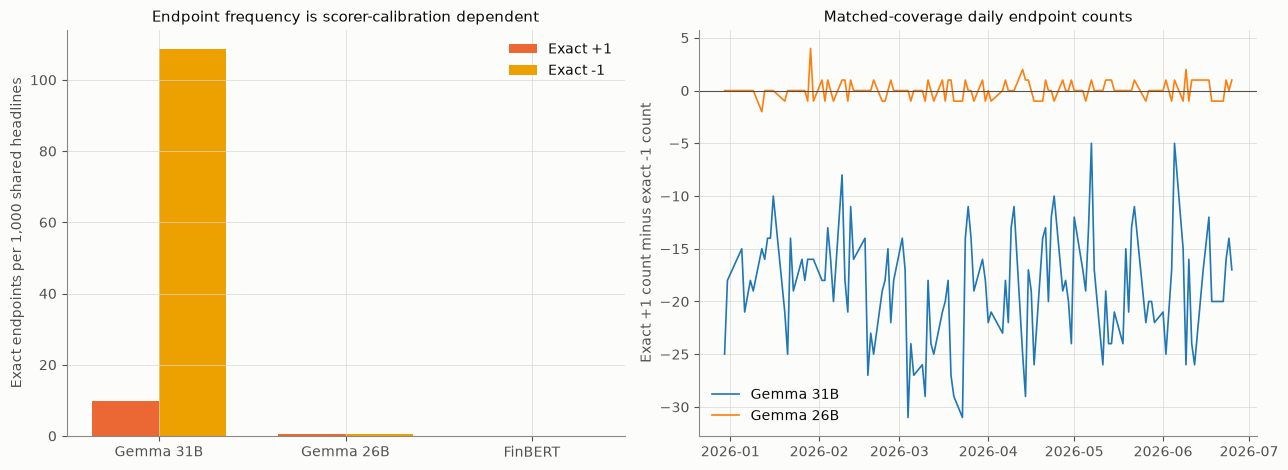

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
endpoint_plot = headline_endpoints.set_index("scorer").loc[
    ["gemma31_cerebras", "gemma26_deepinfra", "finbert"]
]
x = np.arange(len(endpoint_plot))
axes[0].bar(
    x - 0.18,
    endpoint_plot["exact_positive"] / endpoint_plot["shared_headlines"] * 1_000,
    width=0.36,
    color=CATEGORICAL[1],
    label="Exact +1",
)
axes[0].bar(
    x + 0.18,
    endpoint_plot["exact_negative"] / endpoint_plot["shared_headlines"] * 1_000,
    width=0.36,
    color=CATEGORICAL[3],
    label="Exact -1",
)
axes[0].set_xticks(x, ["Gemma 31B", "Gemma 26B", "FinBERT"])
axes[0].set_ylabel("Exact endpoints per 1,000 shared headlines")
axes[0].set_title("Endpoint frequency is scorer-calibration dependent")
axes[0].legend(loc="best")

schedule_plot = pd.DataFrame({"session_date": sorted(common_complete_sessions)})
for label, audit in (("Gemma 31B", audit31), ("Gemma 26B", audit26)):
    aligned = audit.reindex(schedule_plot["session_date"])
    axes[1].plot(
        schedule_plot["session_date"],
        aligned["positive_names"] - aligned["negative_names"],
        linewidth=1.2,
        label=label,
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_ylabel("Exact +1 count minus exact -1 count")
axes[1].set_title("Matched-coverage daily endpoint counts")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "endpoint_calibration_and_schedule.png", dpi=170, bbox_inches="tight")
plt.show()

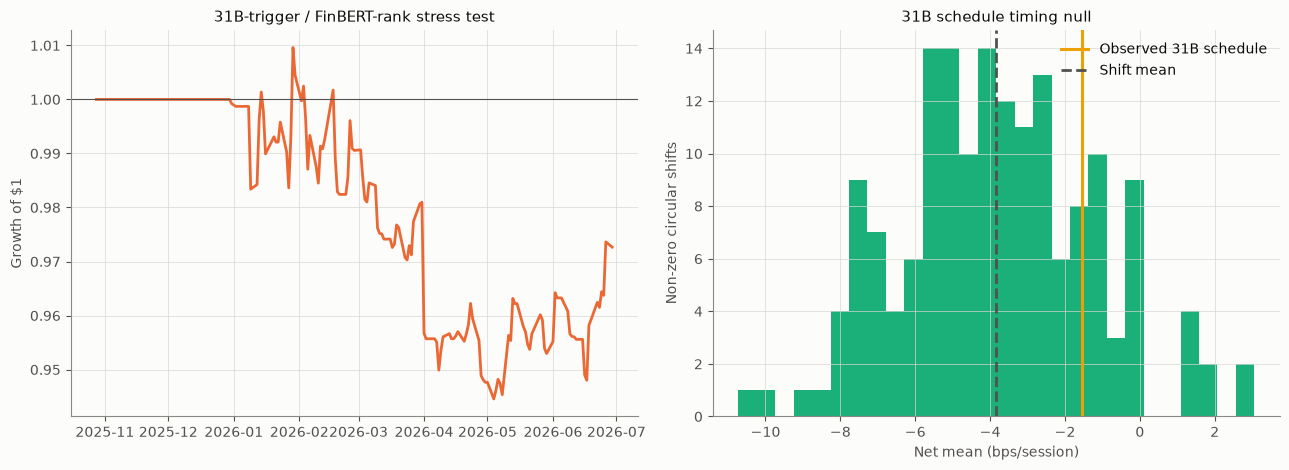

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    observed_daily["return_end_date"],
    (1.0 + observed_daily["net_return"]).cumprod(),
    color=CATEGORICAL[1],
)
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("31B-trigger / FinBERT-rank stress test")
axes[1].hist(shift_null["mean_net"] * 10_000, bins=28, color=CATEGORICAL[2])
axes[1].axvline(
    observed["mean_net"] * 10_000,
    color=CATEGORICAL[3],
    linewidth=2.2,
    label="Observed 31B schedule",
)
axes[1].axvline(
    shift_null["mean_net"].mean() * 10_000,
    color=INK["reference"],
    linestyle="--",
    label="Shift mean",
)
axes[1].set_xlabel("Net mean (bps/session)")
axes[1].set_ylabel("Non-zero circular shifts")
axes[1].set_title("31B schedule timing null")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gemma31_strategy_and_timing.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [8]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
headline_endpoints.to_csv(OUTPUT_DIR / "headline_endpoint_audit.csv", index=False)
firm_endpoints.to_csv(OUTPUT_DIR / "firm_open_endpoint_audit.csv", index=False)
transfer_audit.to_csv(OUTPUT_DIR / "calibration_transfer_audit.csv", index=False)
schedule31.to_csv(OUTPUT_DIR / "gemma31_full_grid_schedule.csv", index=False)
observed_result.to_csv(OUTPUT_DIR / "gemma31_strategy_result.csv", index=False)
cash_inference.to_csv(OUTPUT_DIR / "gemma31_cash_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "gemma31_cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "gemma31_temporal.csv", index=False)
shift_null.to_csv(OUTPUT_DIR / "gemma31_circular_shift_null.csv", index=False)
timing_inference.to_csv(OUTPUT_DIR / "gemma31_timing_inference.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
observed_daily.to_parquet(OUTPUT_DIR / "gemma31_observed_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_GEMMA_EXACT_TRIGGER_CALIBRATION_TRANSFER",
    "notebook": "37_gemma_calibration_transfer.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma31_partial_checkpoint": str(GEMMA31_PATH.relative_to(REPO_ROOT)),
        "gemma31_checkpoint_sha256": sha256_file(GEMMA31_PATH),
        "gemma26_complete_checkpoint": str(GEMMA26_PATH.relative_to(REPO_ROOT)),
        "finbert_complete_checkpoint": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "shared_successful_hashes": len(shared_hashes),
        "licensed_headline_text_loaded": False,
    },
    "specification": {
        "primary": "input-only exact-endpoint calibration-transfer gate",
        "return_stop": "minimum 60 eligible matched-coverage sessions per scorer",
        "permitted_return_arm": "Gemma31 schedule plus complete FinBERT rank, 25%-capped",
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "timing_null": "all 166 non-zero circular shifts of embedded 167-session schedule",
        "cash_inference": f"{REPLICATIONS} five-session circular-block replications",
        "final_liquidation": True,
    },
    "headline_endpoints": json.loads(headline_endpoints.to_json(orient="records")),
    "firm_open_endpoints": json.loads(firm_endpoints.to_json(orient="records")),
    "transfer_audit": json.loads(transfer_audit.to_json(orient="records"))[0],
    "gemma31_strategy_result": json.loads(observed_result.to_json(orient="records"))[0],
    "gemma31_cash_inference": json.loads(cash_inference.to_json(orient="records"))[0],
    "gemma31_temporal": json.loads(temporal.to_json(orient="records")),
    "gemma31_timing_inference": json.loads(
        timing_inference.to_json(orient="records")
    )[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "the older Gemma31 checkpoint has no completed adjacent manifest",
        "Gemma31 is partial hash-ordered coverage after a failed Cerebras run",
        "Gemma31 and Gemma26 use different models, providers, and prompts",
        "the exact numeric endpoint is a calibration property, not a semantic class",
        "canonical metadata comes from the later complete 44-company checkpoint",
        "the 31B return arm uses the same already-opened eight-month return window",
        "dates lacking a rectangular partial-score panel remain cash",
        "circular shifts assume approximate stationarity and wrap endpoints",
        "the 31B return arm is a stress test, not a scorer comparison or deployable policy",
        "human validation of the complete 26B labels remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_GEMMA_EXACT_TRIGGER_CALIBRATION_TRANSFER",
  "notebook": "37_gemma_calibration_transfer.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260811,
  "input": {
    "gemma31_partial_checkpoint": "Data/collections/lseg_us_sector_33_6m/derived/headline_scores_gemma-4-31b_soft.csv",
    "gemma31_checkpoint_sha256": "3909dabfd0b4c6f93b5b786c4e361f159156cb42c819a4d30cbbb72cc5d28b41",
    "gemma26_complete_checkpoint": "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv",
    "finbert_complete_checkpoint": "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_finbert4556_cacheonly_20260803.csv",
    "shared_successful_hashes": 85960,
    "licensed_headline_text_loaded": false
  },
  "specification": {
    "primary": "input-only exact-endpoint calibration-transfer gate",
    "return_stop": "minimum 60 el

## Decision

The exact-endpoint construction **fails the calibration-transfer gate
decisively**. On the same 85,960 headlines, Cerebras Gemma 31B emits 10,172
exact +/-1 scores versus 95 for DeepInfra Gemma 26B, a 107.1-fold difference;
FinBERT emits none. After identical aggregation on 3,894 complete firm-opens,
31B is eligible on 84/118 sessions while matched-coverage 26B is eligible on
only 6/118. The schedules share just 5 eligible dates out of 85 in their union
(Jaccard 0.059), and positive/negative daily count correlations are only 0.035
and 0.016. The 26B arm therefore stops before return testing under the frozen
60-session floor.

The permitted 31B-trigger/FinBERT-rank stress test is also negative. At 10 bps
per traded side, its gross/net Sharpe is 1.624/-0.543, total net return is
-2.73%, maximum drawdown is -6.44%, and break-even cost is only 7.50 bps per
side. Its cash-relative block interval is [-7.322,+3.980] bps/session
(p=0.588). Independently initialized half-sample net Sharpes are -0.387 and
-0.738. The observed schedule is better than the average circular shift by
2.282 bps/session but only at the 80.1st percentile (one-sided p=0.204), so the
timing gate fails.

**Decision: preserve Notebook 36's 26B hybrid as the leading same-window
candidate, but withdraw any claim that an exact numeric +/-1 event is a
portable semantic trigger.** It is highly sensitive to model, prompt,
provider, and probability quantization. A future independent replay must
replace the endpoint equality with a semantically defined, calibration-aware
event rule frozen without reference to these returns; no threshold may be
chosen on the current 167 sessions. Notebook 37 is a useful measurement and
implementation falsification, not evidence that Gemma sentiment is useless.